In [75]:
from lsst.rsp import get_tap_service, retrieve_query
from lsst.utils.plotting import set_rubin_plotstyle, stars_cmap, get_multiband_plot_colors 
from statsmodels.distributions.empirical_distribution import ECDF
import matplotlib.pyplot as plt
import numpy as np
colors = get_multiband_plot_colors()
bands = colors.keys()

In [3]:
service = get_tap_service("tap")

In [147]:
query = "SELECT band, "\
        "scisql_nanojanskyToAbMag(psfFlux) as psfMag "\
        "FROM dp1.Source "\
        "WHERE extendedness < 0.5 AND scisql_nanojanskyToAbMagSigma(psfFlux, psfFluxErr) < 0.2 "
job = service.submit_job(query)
print('Job URL is', job.url)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
sources = job.fetch_result().to_table()
print('Number of sources is ', len(sources))

Job URL is https://usdf-rsp.slac.stanford.edu/api/tap/async/q640n1q6s8iwsu2u
Job phase is COMPLETED
Number of sources is  14529970


In [148]:
query = "SELECT coord_ra, coord_dec, "\
        "scisql_nanojanskyToAbMag(u_psfFlux) as umag, scisql_nanojanskyToAbMagSigma(u_psfFlux, u_psfFluxErr) as umagErr, "\
        "scisql_nanojanskyToAbMag(g_psfFlux) as gmag, scisql_nanojanskyToAbMagSigma(g_psfFlux, g_psfFluxErr) as gmagErr, "\
        "scisql_nanojanskyToAbMag(r_psfFlux) as rmag, scisql_nanojanskyToAbMagSigma(r_psfFlux, r_psfFluxErr) as rmagErr, "\
        "scisql_nanojanskyToAbMag(i_psfFlux) as imag, scisql_nanojanskyToAbMagSigma(i_psfFlux, i_psfFluxErr) as imagErr, "\
        "scisql_nanojanskyToAbMag(z_psfFlux) as zmag, scisql_nanojanskyToAbMagSigma(z_psfFlux, z_psfFluxErr) as zmagErr, "\
        "scisql_nanojanskyToAbMag(y_psfFlux) as ymag, scisql_nanojanskyToAbMagSigma(y_psfFlux, y_psfFluxErr) as ymagErr "\
        "FROM dp1.Object "\
        "WHERE refExtendedness < 0.5 AND scisql_nanojanskyToAbMagSigma(i_psfFlux, i_psfFluxErr) < 0.2"
job = service.submit_job(query)
print('Job URL is', job.url)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
objects = job.fetch_result().to_table()
print('Number of objects is ', len(objects))

Job URL is https://usdf-rsp.slac.stanford.edu/api/tap/async/ao8mvfhx1ttpgdt9
Job phase is COMPLETED
Number of objects is  281375


/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)
/tmp/ipykernel_3608/2831446350.py:37: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(
/tmp/ipykernel_3608/2831446350.py:37: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(
/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


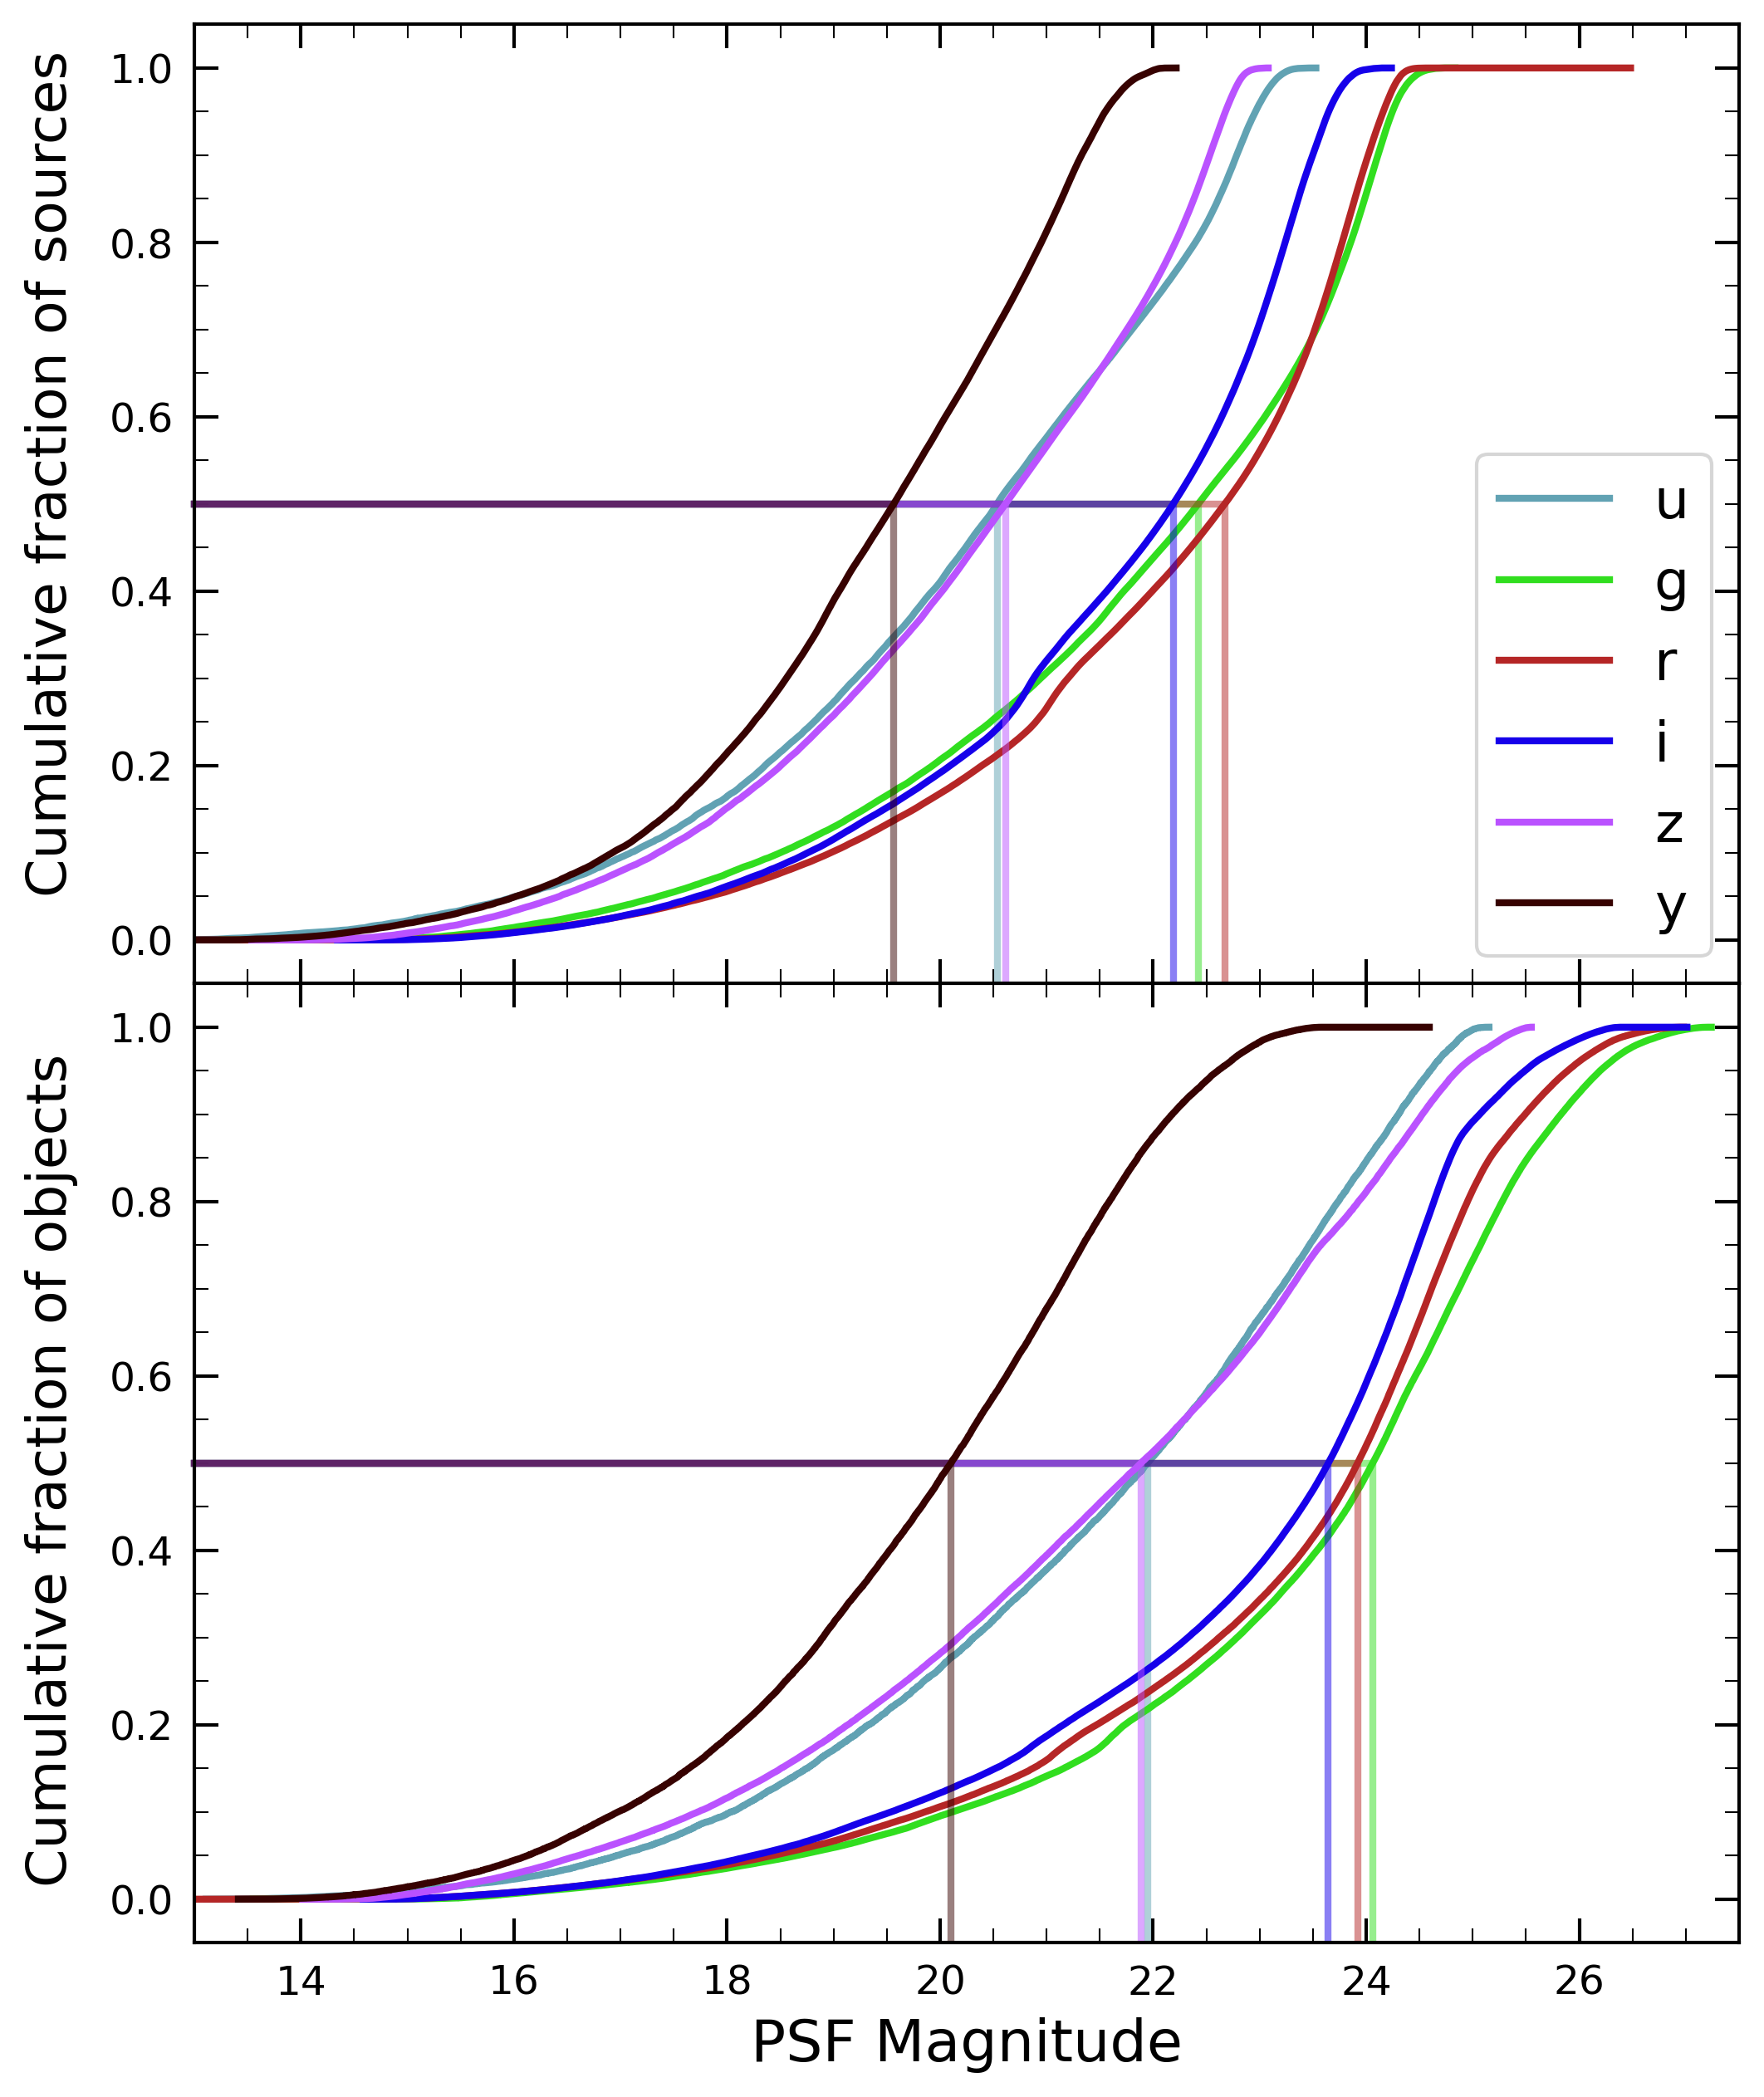

In [152]:
set_rubin_plotstyle()
colors = get_multiband_plot_colors()
bands = colors.keys()

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 10))
fig.subplots_adjust(hspace=0)
ax1.tick_params(labelbottom=False)

for band in bands:
    mask = sources['band'] == band
    data = sources['psfMag'][mask]
    ecdf = ECDF(data)
    ax1.plot(ecdf.x, ecdf.y,
             linestyle='-', label=band, color=colors[band])
    ax1.plot([13, np.median(data), np.median(data)],[0.5,0.5,-0.045],
             color=colors[band], alpha=0.5, clip_on=False)
    
ax1.set_ylim(-0.05, 1.05)

ax1.legend(fontsize=16)
fig.text(0.04, 0.7, 'Cumulative fraction of sources', va='center', rotation='vertical', size=16)

for band in bands:
    data = objects[band+'mag'][objects[band+'magErr']<0.2]
    ecdf = ECDF(data)
    ax2.plot(ecdf.x, ecdf.y,
             linestyle='-', label=band, color=colors[band])
    ax2.plot([13, np.median(data), np.median(data)],[0.5,0.5,-0.045],
             color=colors[band], alpha=0.5, clip_on=False)

ax2.set_xlim(13, 27.5)
ax2.set_ylim(-0.05, 1.05)

fig.text(0.04, 0.3, 'Cumulative fraction of objects', va='center', rotation='vertical', size=16)
ax2.set_xlabel('PSF Magnitude')

plt.savefig(
   "../dp1_mag_cum_hists.pdf", 
   bbox_inches="tight",  # Trim whitespace around the figure
   transparent=True,     # Transparent background
   format="pdf",         # Explicit format specification
)

plt.show()


/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


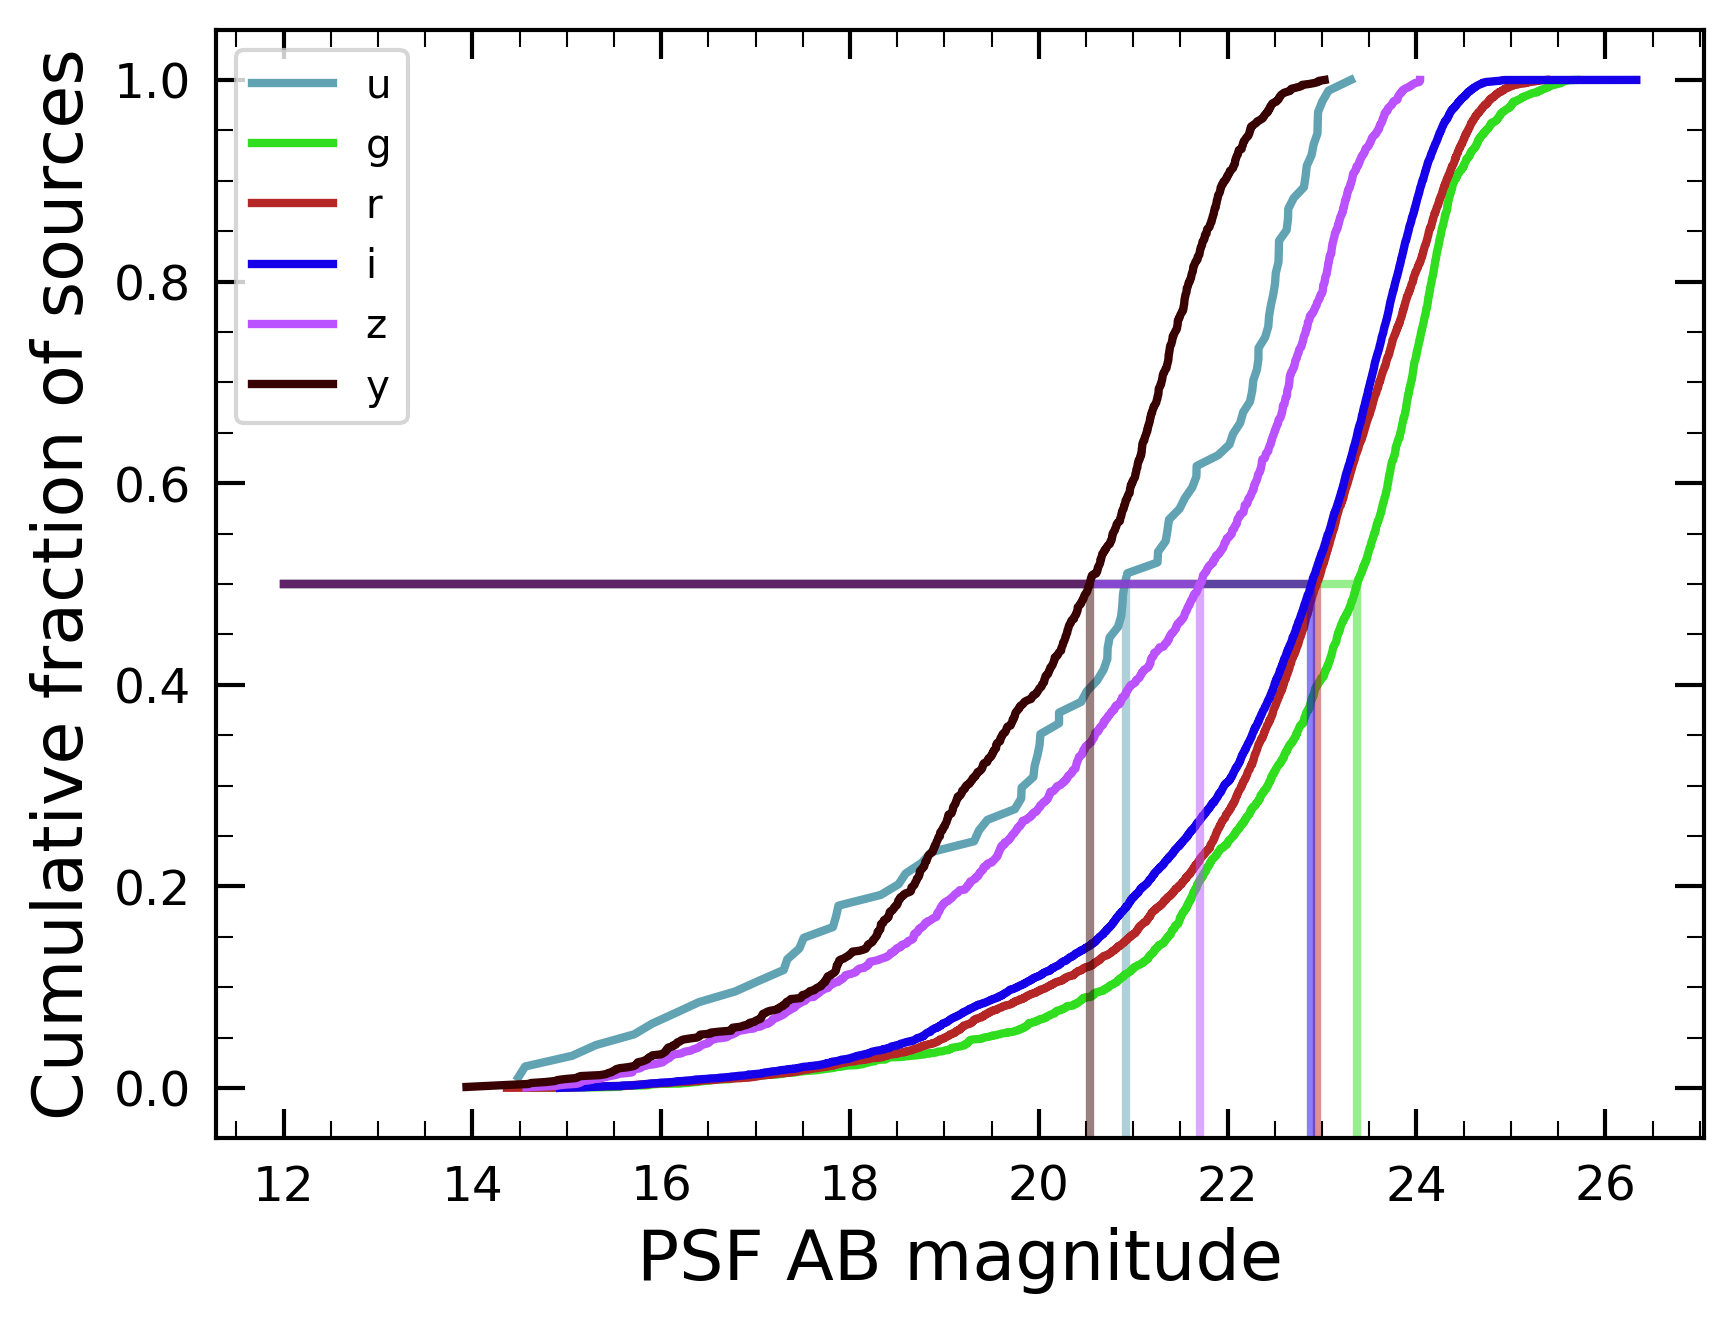

In [127]:
set_rubin_plotstyle()
colors = get_multiband_plot_colors()
bands = colors.keys()

for band in bands:
    data = objects[band+'mag'][objects[band+'magErr']<0.2]
    ecdf = ECDF(data)
    plt.plot(ecdf.x, ecdf.y,
             linestyle='-', label=band, color=colors[band])
    plt.plot([12, np.median(data), np.median(data)],[0.5,0.5,-0.045],
             color=colors[band], alpha=0.5, clip_on=False)
    
plt.legend()
plt.ylim(-0.05, 1.05)
plt.xlabel('PSF AB magnitude')
plt.ylabel('Cumulative fraction of sources')
plt.savefig(
    "../dp1_source_mag_cum_hists.pdf", 
    bbox_inches="tight",  # Trim whitespace around the figure
    transparent=True,     # Transparent background
    format="pdf",         # Explicit format specification
)

plt.show()


In [ ]:
query = "SELECT TOP 10000 coord_ra, coord_dec "\
        "scisql_nanojanskyToAbMag(u_psfFlux) as umag, scisql_nanojanskyToAbMagSigma(u_psfFlux, u_psfFluxErr) as umagErr, u_psfFlux_flag, "\
        "scisql_nanojanskyToAbMag(g_psfFlux) as gmag, scisql_nanojanskyToAbMagSigma(g_psfFlux, g_psfFluxErr) as gmagErr, g_psfFlux_flag, "\
        "scisql_nanojanskyToAbMag(r_psfFlux) as rmag, scisql_nanojanskyToAbMagSigma(r_psfFlux, r_psfFluxErr) as rmagErr, r_psfFlux_flag, "\
        "scisql_nanojanskyToAbMag(i_psfFlux) as imag, scisql_nanojanskyToAbMagSigma(i_psfFlux, i_psfFluxErr) as imagErr, i_psfFlux_flag, "\
        "scisql_nanojanskyToAbMag(z_psfFlux) as zmag, scisql_nanojanskyToAbMagSigma(z_psfFlux, z_psfFluxErr) as zmagErr, z_psfFlux_flag, "\
        "scisql_nanojanskyToAbMag(y_psfFlux) as ymag, scisql_nanojanskyToAbMagSigma(y_psfFlux, y_psfFluxErr) as ymagErr, y_psfFlux_flag "\
        "FROM dp1.Object "\
        "WHERE refExtendedness < 0.5 AND scisql_nanojanskyToAbMagSigma(i_psfFlux, i_psfFluxErr) < 0.2"
